# 02 — Grating Spectrum with Broad-Line Detection

This notebook demonstrates fitting G395M grating spectra with automatic
BIC-based broad Balmer component detection.

The G395M grating has R ≈ 1000 (constant), resolving [NII]–Hα–[NII] and
[SII] doublets that are blended in the prism.  The broad component fitting
uses `fit_with_broad(mode="auto")` which compares narrow-only vs broad
models via BIC and selects the best one in a single call.

In [1]:
import jwspecfit
import matplotlib.pyplot as plt
import numpy as np

## Second G395M spectrum

In [3]:
spec2 = jwspecfit.read_fits(
    "../../data/stark-rxcj2248-v4_g395m-f290lp_2478_3.spec.fits",
    z=6.1052,
)

result2 = jwspecfit.fit_with_broad(spec2, z=6.1052, mode="auto",deg=3)


print(f"Selected model: {result2.selected_model}")
print(f"χ²/dof = {result2.best_fit.chi2:.2f}")
for name, lr in result2.best_fit.lines.items():
    if lr.snr > 1:
        print(f"  {name:<18s} flux={lr.flux:.2e} ± {lr.flux_err:.2e}  SNR={lr.snr:.1f}")

Bootstrap (broad1): 100%|██████████| 1000/1000 [00:54<00:00, 18.50iter/s]

Selected model: broad1
χ²/dof = 1.28
  HDELTA             flux=1.86e-18 ± 7.17e-19  SNR=2.6
  HGAMMA             flux=5.61e-18 ± 1.21e-18  SNR=4.7
  OIII_4363          flux=6.20e-18 ± 7.44e-19  SNR=8.3
  HBETA              flux=1.56e-17 ± 1.18e-18  SNR=13.2
  OIII_4959          flux=3.00e-17 ± 9.98e-19  SNR=30.1
  OIII_5007          flux=8.78e-17 ± 1.08e-18  SNR=81.5
  NII_5756           flux=3.97e-19 ± 2.67e-19  SNR=1.5
  HEI_5877           flux=3.01e-18 ± 4.43e-19  SNR=6.8
  NII_6549           flux=4.99e-19 ± 1.73e-20  SNR=28.9
  Ha                 flux=3.94e-17 ± 8.92e-19  SNR=44.2
  NII_6585           flux=1.48e-18 ± 5.11e-20  SNR=28.9
  SII_6718           flux=1.19e-18 ± 4.76e-19  SNR=2.5
  SII_6732           flux=4.76e-19 ± 3.91e-19  SNR=1.2
  Ha_BROAD           flux=1.27e-17 ± 1.98e-18  SNR=6.4
  HBETA_BROAD        flux=3.72e-18 ± 1.18e-18  SNR=3.2
  HDELTA_BROAD       flux=5.20e-18 ± 9.96e-19  SNR=5.2
  HGAMMA_BROAD       flux=3.74e-18 ± 9.61e-19  SNR=3.9


/Users/raunaqrai/miniforge3/envs/jwst/lib/python3.12/site-packages/jwspecfit/plotting.py:284: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


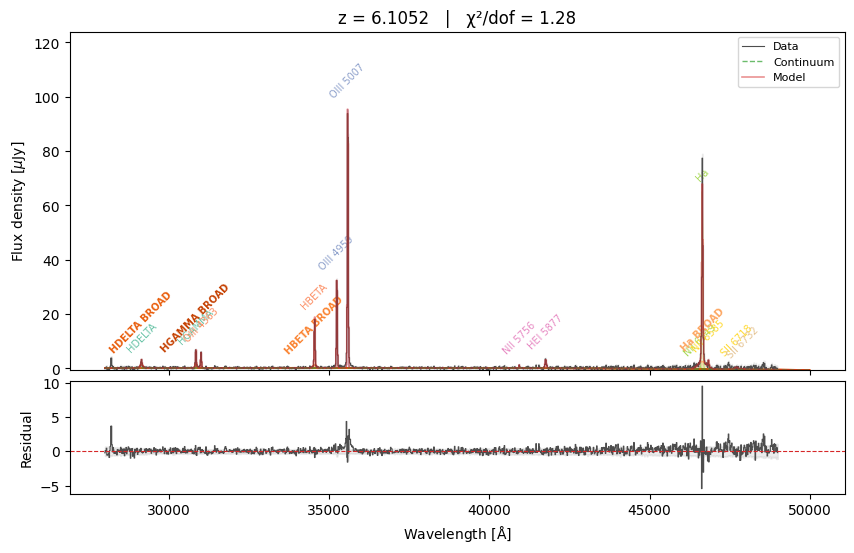

In [4]:
fig = jwspecfit.plot_fit(result2.best_fit,exclude_wave_A=[(20000, 28000),(50000,60000)])
plt.show()

## Interactive plot

Use the plotly interactive plot to zoom into the Hα+[NII] complex
and inspect narrow vs broad components.

In [5]:
fig_interactive = jwspecfit.plot_fit_interactive(result2.best_fit)
fig_interactive.show()

## Save results and export line table

In [6]:
# Save the fit result for replotting later
jwspecfit.save_result(result2.best_fit, "g395m_fit_result.npz")

# Export line measurements
jwspecfit.export_lines_txt(result2.best_fit, "g395m_lines.txt")

with open("g395m_lines.txt") as f:
    print(f.read())

# jwspecfit line measurements  z=6.105200
# flux units: erg/s/cm2  |  EW units: rest-frame Angstrom
# name                   rest_A   centroid_A           flux       flux_err       EW_A  sigma_v_kms    SNR_int   SNR_peak
  HDELTA               4104.050    29153.540   1.859017e-18   7.173390e-19     45.637       107.09       2.59       4.21
  HGAMMA               4342.905    30850.269   5.614436e-18   1.206456e-18    134.063       107.09       4.65      10.72
  OIII_4363            4364.436    31009.186   6.203958e-18   7.442979e-19    148.008       125.58       8.34      15.47
  HBETA                4864.041    34552.218   1.558284e-17   1.181797e-18    396.022       107.09      13.19      26.86
  OIII_4959            4961.679    35245.745   3.004871e-17   9.979067e-19    789.321       105.36      30.11      42.33
  OIII_5007            5009.637    35586.471   8.778806e-17   1.077440e-18   2351.490       107.09      81.48      72.37
  NII_5756             5757.787    40934.523   3.9728